# Benchmark: Parquet vs Tablas Materializadas (DuckDB)
Este notebook carga los resultados del benchmark generado por `scripts/benchmark.py` y produce gráficos para visualizar los tiempos de ejecución de ambas estrategias (Parquet directo vs Tabla materializada).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los resultados del CSV
df = pd.read_csv('../data/processed/benchmark_results.csv')

# Inspeccionar los datos
df.head()

,volumen,consulta,mediana_parquet_ms,mediana_tabla_ms,speedup,repeticiones
0,1 mes (yellow ene-2024),Q1 Agregacion,12.0,30.6,0.39,5
1,1 mes (yellow ene-2024),Q2 Filtro,12.6,30.4,0.41,5
2,1 mes (yellow ene-2024),Q3 Temporal,63.6,37.4,1.70,5
3,1 mes (yellow ene-2024),Q4 JOIN zonas,52.3,33.0,1.58,5
4,1 mes (yellow ene-2024),Q5 Top-N window,39.9,30.7,1.30,5


## Visualización de Tiempos por Volumen y Consulta
A continuación comparamos las medianas de los tiempos de ejecución (en milisegundos) agrupados por el volumen de datos.

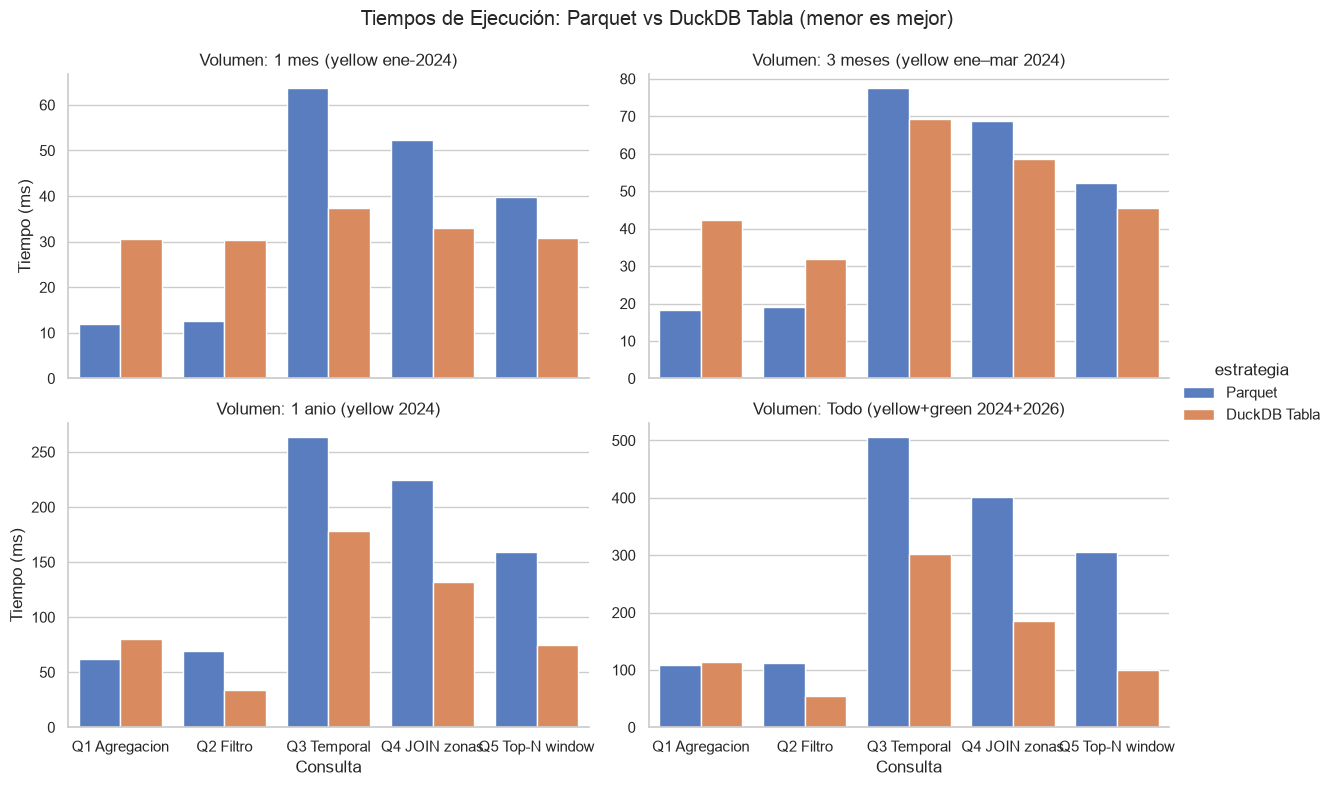

In [2]:
# Configuración estética
sns.set_theme(style="whitegrid")

# Convertir tipos por seguridad
df['mediana_parquet_ms'] = pd.to_numeric(df['mediana_parquet_ms'], errors='coerce')
df['mediana_tabla_ms'] = pd.to_numeric(df['mediana_tabla_ms'], errors='coerce')

# Transformar de ancho a largo para seaborn
df_melt = df.melt(id_vars=['volumen', 'consulta'], 
                  value_vars=['mediana_parquet_ms', 'mediana_tabla_ms'],
                  var_name='estrategia', value_name='tiempo_ms')

df_melt['estrategia'] = df_melt['estrategia'].replace({
    'mediana_parquet_ms': 'Parquet',
    'mediana_tabla_ms': 'DuckDB Tabla'
})

g = sns.catplot(
    data=df_melt, kind="bar",
    x="consulta", y="tiempo_ms", hue="estrategia", col="volumen",
    col_wrap=2, height=4, aspect=1.5, palette="muted",
    sharey=False # para que cada volumen ajuste su escala
)
g.set_axis_labels("Consulta", "Tiempo (ms)")
g.set_titles("Volumen: {col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Tiempos de Ejecución: Parquet vs DuckDB Tabla (menor es mejor)')
plt.show()

## Análisis del Speedup
El speedup indica cuántas veces más rápida es la tabla de DuckDB respecto a leer directamente Parquet. 
Un valor > 1.0 significa que la **tabla materializada es más rápida**.
Un valor < 1.0 significa que **Parquet directo es más rápido**.

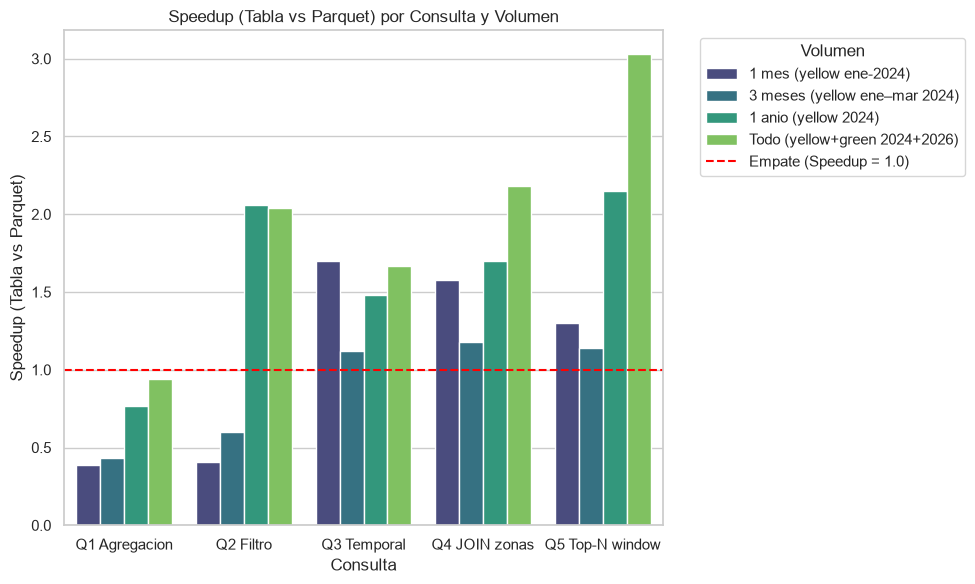

In [3]:
# Convertir speedup a numerico
df['speedup'] = pd.to_numeric(df['speedup'], errors='coerce')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df, x='consulta', y='speedup', hue='volumen', palette='viridis')

# Línea de referencia en 1.0 (empate)
plt.axhline(1.0, color='red', linestyle='--', label='Empate (Speedup = 1.0)')

plt.title('Speedup (Tabla vs Parquet) por Consulta y Volumen')
plt.ylabel('Speedup (Tabla vs Parquet)')
plt.xlabel('Consulta')
plt.legend(title='Volumen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()